In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,RobustScaler
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.dates as mdates
import seaborn as sns
import torch.nn as nn
import copy
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [109]:
df = pd.read_csv("data/CVX_2006-01-01_to_2018-01-01.csv")
df

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,57.25,59.10,57.06,59.08,13296500,CVX
1,2006-01-04,59.08,59.08,58.43,58.91,8838800,CVX
2,2006-01-05,58.68,58.96,57.85,58.19,8634800,CVX
3,2006-01-06,58.95,59.57,58.59,59.25,9609000,CVX
4,2006-01-09,59.49,59.58,58.55,58.95,6442300,CVX
...,...,...,...,...,...,...,...
3015,2017-12-22,124.85,125.65,124.57,124.98,4735086,CVX
3016,2017-12-26,125.23,126.14,125.05,125.98,3348496,CVX
3017,2017-12-27,125.96,126.20,125.13,125.55,3452329,CVX
3018,2017-12-28,125.69,125.89,125.29,125.58,2191821,CVX


In [110]:
def add_sma(df, period=14):
    df[f'SMA_{period}'] = df['Close'].rolling(window=period).mean()
    return df

def add_ema(df, period=14):
    df[f'EMA_{period}'] = df['Close'].ewm(span=period, adjust=False).mean()
    return df

def add_rsi(df, period=14):
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

def add_macd(df, fast=12, slow=26, signal=9):
    ema_fast = df['Close'].ewm(span=fast, adjust=False).mean()
    ema_slow = df['Close'].ewm(span=slow, adjust=False).mean()
    df['MACD'] = ema_fast - ema_slow
    df['MACD_signal'] = df['MACD'].ewm(span=signal, adjust=False).mean()
    df['MACD_hist'] = df['MACD'] - df['MACD_signal']
    return df

def add_bollinger(df, period=20, std=2):
    sma = df['Close'].rolling(window=period).mean()
    rolling_std = df['Close'].rolling(window=period).std()
    df['BB_upper'] = sma + std * rolling_std
    df['BB_lower'] = sma - std * rolling_std
    df['BB_width'] = df['BB_upper'] - df['BB_lower']
    return df

def add_atr(df, period=14):
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift())
    low_close = np.abs(df['Low'] - df['Close'].shift())
    true_range = np.maximum(high_low, np.maximum(high_close, low_close))
    df['ATR'] = true_range.rolling(window=period).mean()
    return df

def add_obv(df):
    df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).fillna(0).cumsum()
    return df

df = add_sma(df, 14)
df = add_sma(df, 50)
df = add_ema(df, 14)
df = add_rsi(df, 14)
df = add_macd(df)
df = add_bollinger(df)
df = add_atr(df)
df = add_obv(df)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(len(df))
df


2957


,Date,Open,High,Low,Close,Volume,Name,SMA_14,SMA_50,EMA_14,RSI,MACD,MACD_signal,MACD_hist,BB_upper,BB_lower,BB_width,ATR,OBV
0,2006-03-15,56.50,56.60,55.68,56.50,8741100,CVX,56.092857,58.1616,56.023617,46.009975,-0.711339,-0.783094,0.071755,58.478276,54.222724,4.255552,1.022857,-73401400.0
1,2006-03-16,56.51,58.03,56.28,57.74,11253200,CVX,56.099286,58.1348,56.252468,50.514286,-0.513983,-0.729272,0.215289,58.645954,54.233046,4.412909,1.088571,-62148200.0
2,2006-03-17,57.98,58.04,57.02,57.18,9385900,CVX,56.105000,58.1002,56.376139,50.456621,-0.398174,-0.663052,0.264878,58.713216,54.253784,4.459432,1.113571,-71534100.0
3,2006-03-20,57.00,57.43,56.65,56.75,6877300,CVX,56.124286,58.0714,56.425987,51.575263,-0.337205,-0.597883,0.260678,58.672819,54.252181,4.420638,1.107143,-78411400.0
4,2006-03-21,56.60,57.10,56.15,56.57,6231400,CVX,56.076429,58.0178,56.445189,45.807259,-0.299954,-0.538297,0.238343,58.501776,54.290224,4.211551,1.117143,-84642800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2952,2017-12-22,124.85,125.65,124.57,124.98,4735086,CVX,120.647857,118.0954,120.872702,73.154362,1.498695,1.033546,0.465149,124.274160,115.488840,8.785321,1.470714,476666440.0
2953,2017-12-26,125.23,126.14,125.05,125.98,3348496,CVX,121.047143,118.2318,121.553675,79.452055,1.771735,1.181184,0.590552,125.103308,115.698692,9.404616,1.464286,480014936.0
2954,2017-12-27,125.96,126.20,125.13,125.55,3452329,CVX,121.471429,118.3402,122.086518,82.494530,1.931163,1.331180,0.599984,125.707302,116.004698,9.702604,1.443571,476562607.0
2955,2017-12-28,125.69,125.89,125.29,125.58,2191821,CVX,121.896429,118.4474,122.552316,82.513661,2.036457,1.472235,0.564222,126.240444,116.311556,9.928887,1.405000,478754428.0


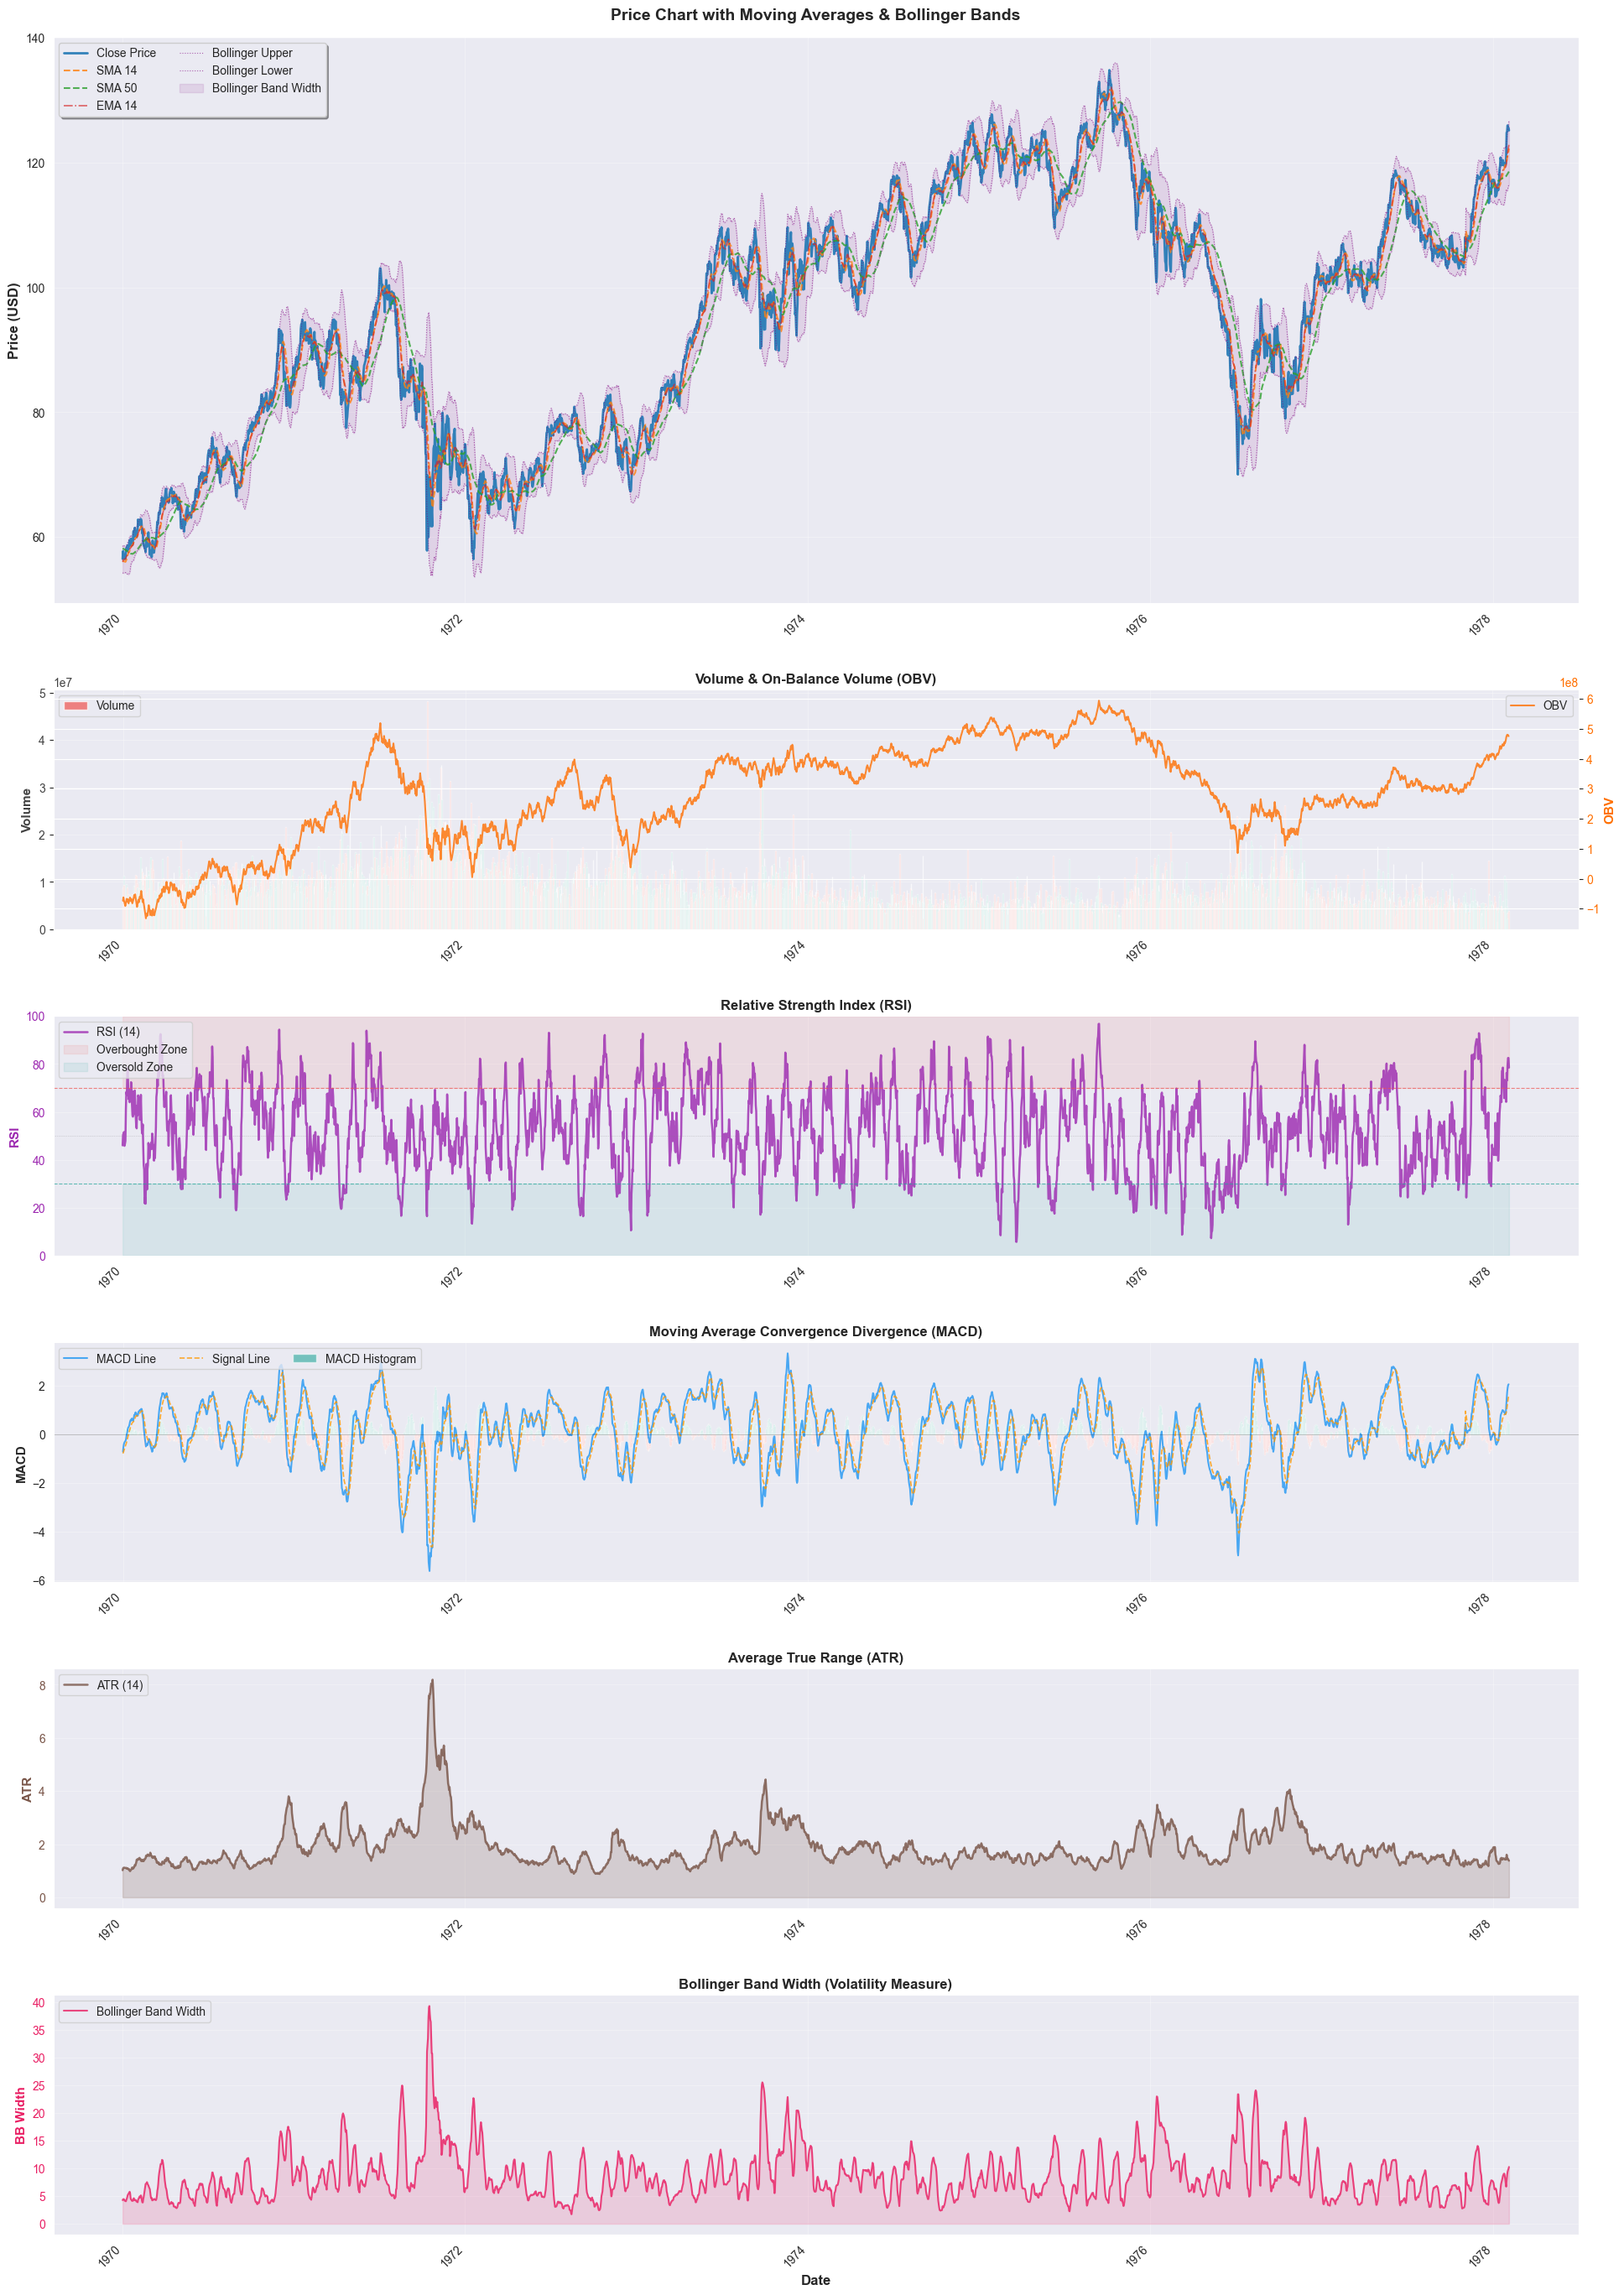

In [111]:
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (18, 24)
plt.rcParams['font.size'] = 10

fig = plt.figure(figsize=(20, 28))

ax1 = plt.subplot2grid((7, 1), (0, 0), rowspan=2)
ax1.plot(df['Date'], df['Close'], linewidth=2, color='#1f77b4', label='Close Price', alpha=0.9)
ax1.plot(df['Date'], df['SMA_14'], linewidth=1.5, color='#ff7f0e', linestyle='--', label='SMA 14', alpha=0.8)
ax1.plot(df['Date'], df['SMA_50'], linewidth=1.5, color='#2ca02c', linestyle='--', label='SMA 50', alpha=0.8)
ax1.plot(df['Date'], df['EMA_14'], linewidth=1.2, color='#d62728', linestyle='-.', label='EMA 14', alpha=0.7)

ax1.plot(df['Date'], df['BB_upper'], linewidth=0.8, color='purple', linestyle=':', label='Bollinger Upper', alpha=0.6)
ax1.plot(df['Date'], df['BB_lower'], linewidth=0.8, color='purple', linestyle=':', label='Bollinger Lower', alpha=0.6)
ax1.fill_between(df['Date'], df['BB_upper'], df['BB_lower'], alpha=0.1, color='purple', label='Bollinger Band Width')

ax1.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
ax1.set_title('Price Chart with Moving Averages & Bollinger Bands', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='upper left', ncol=2, frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3)


ax2 = plt.subplot2grid((7, 1), (2, 0))
color_volume = np.where(df['Close'].diff() > 0, '#26a69a', '#ef5350')
ax2.bar(df['Date'], df['Volume'], color=color_volume, alpha=0.7, width=1.5, label='Volume')
ax2.set_ylabel('Volume', fontsize=11, fontweight='bold', color='#424242')
ax2.tick_params(axis='y', labelcolor='#424242')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

ax2b = ax2.twinx()
ax2b.plot(df['Date'], df['OBV'], linewidth=1.5, color='#ff6f00', alpha=0.8, label='OBV')
ax2b.set_ylabel('OBV', fontsize=11, fontweight='bold', color='#ff6f00')
ax2b.tick_params(axis='y', labelcolor='#ff6f00')
ax2b.legend(loc='upper right')
ax2.set_title('Volume & On-Balance Volume (OBV)', fontsize=12, fontweight='bold')


ax3 = plt.subplot2grid((7, 1), (3, 0))
ax3.plot(df['Date'], df['RSI'], linewidth=1.8, color='#9c27b0', label='RSI (14)', alpha=0.8)
ax3.fill_between(df['Date'], 70, 100, alpha=0.1, color='#ef5350', label='Overbought Zone')
ax3.fill_between(df['Date'], 0, 30, alpha=0.1, color='#26a69a', label='Oversold Zone')
ax3.axhline(y=70, color='#ef5350', linestyle='--', linewidth=0.8, alpha=0.7)
ax3.axhline(y=30, color='#26a69a', linestyle='--', linewidth=0.8, alpha=0.7)
ax3.axhline(y=50, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)
ax3.set_ylabel('RSI', fontsize=11, fontweight='bold', color='#9c27b0')
ax3.set_ylim(0, 100)
ax3.tick_params(axis='y', labelcolor='#9c27b0')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left')
ax3.set_title('Relative Strength Index (RSI)', fontsize=12, fontweight='bold')


ax4 = plt.subplot2grid((7, 1), (4, 0))
colors_macd = np.where(df['MACD_hist'] > 0, '#26a69a', '#ef5350')
ax4.bar(df['Date'], df['MACD_hist'], color=colors_macd, alpha=0.6, width=1.5, label='MACD Histogram')
ax4.plot(df['Date'], df['MACD'], linewidth=1.5, color='#2196f3', label='MACD Line', alpha=0.8)
ax4.plot(df['Date'], df['MACD_signal'], linewidth=1.2, color='#ff9800', linestyle='--', label='Signal Line', alpha=0.8)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
ax4.set_ylabel('MACD', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper left', ncol=3)
ax4.set_title('Moving Average Convergence Divergence (MACD)', fontsize=12, fontweight='bold')


ax5 = plt.subplot2grid((7, 1), (5, 0))
ax5.plot(df['Date'], df['ATR'], linewidth=1.8, color='#795548', alpha=0.8, label='ATR (14)')
ax5.fill_between(df['Date'], df['ATR'], alpha=0.2, color='#795548')
ax5.set_ylabel('ATR', fontsize=11, fontweight='bold', color='#795548')
ax5.tick_params(axis='y', labelcolor='#795548')
ax5.grid(True, alpha=0.3)
ax5.legend(loc='upper left')
ax5.set_title('Average True Range (ATR)', fontsize=12, fontweight='bold')


ax6 = plt.subplot2grid((7, 1), (6, 0))
ax6.plot(df['Date'], df['BB_width'], linewidth=1.5, color='#e91e63', alpha=0.8, label='Bollinger Band Width')
ax6.fill_between(df['Date'], df['BB_width'], alpha=0.15, color='#e91e63')
ax6.set_ylabel('BB Width', fontsize=11, fontweight='bold', color='#e91e63')
ax6.tick_params(axis='y', labelcolor='#e91e63')
ax6.set_xlabel('Date', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)
ax6.legend(loc='upper left')
ax6.set_title('Bollinger Band Width (Volatility Measure)', fontsize=12, fontweight='bold')

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout(pad=3.0)
plt.show()

In [112]:
feature_columns = ['Open', 'High', 'Close', 'Low', 'Volume',
                   'SMA_14', 'SMA_50', 'EMA_14', 'RSI',
                   'MACD', 'MACD_signal', 'MACD_hist',
                   'BB_upper', 'BB_lower', 'BB_width', 'ATR', 'OBV']

target_column = 'Close'

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_features = scaler_X.fit_transform(df[feature_columns])
scaled_target = scaler_y.fit_transform(df[[target_column]])

X = torch.tensor(scaled_features, dtype=torch.float32)
y = torch.tensor(scaled_target, dtype=torch.float32)

In [113]:
def create_sequences(X, y, lookback=60):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])
    return torch.stack(X_seq), torch.stack(y_seq)

In [114]:
LOOKBACK = 30
X_seq, y_seq = create_sequences(X, y, LOOKBACK)
print("shape X_seq:", X_seq.shape)
print("shape y_seq:", y_seq.shape)


shape X_seq: torch.Size([2927, 30, 17])
shape y_seq: torch.Size([2927, 1])


In [115]:
class CryptoDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

split = int(0.8 * len(X_seq))
X_train, X_val = X_seq[:split], X_seq[split:]
y_train, y_val = y_seq[:split], y_seq[split:]

batch_size = 64
train_dataset = CryptoDataset(X_train, y_train)
val_dataset = CryptoDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [116]:
import torch
import torch.nn as nn

class AttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, features)
        lstm_out, _ = self.lstm(x)  # (batch, seq_len, hidden_size*2)

        # Attention weights
        attn_weights = self.attention(lstm_out)          # (batch, seq_len, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)

        # Weighted sum
        context = torch.sum(attn_weights * lstm_out, dim=1)  # (batch, hidden_size*2)

        out = self.fc(context)
        return out

In [117]:
input_size = X_seq.shape[2]
model = AttentionLSTM(input_size, hidden_size=128, num_layers=3, dropout=0.2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                         factor=0.5, patience=5)

In [118]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

AttentionLSTM(
  (lstm): LSTM(17, 128, num_layers=3, batch_first=True, dropout=0.2, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [119]:
epochs = 100
patience = 10
best_val_loss = float('inf')
best_model_state = None
early_stop_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    # --- Training ---
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()

        with torch.no_grad():
            y_prev = X_batch[:, -1, 3]  # Close price
            pred_direction = (outputs.squeeze() > y_prev).float()
            true_direction = (y_batch.squeeze() > y_prev).float()
            train_correct += (pred_direction == true_direction).sum().item()
            train_total += y_batch.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = (train_correct / train_total) * 100
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

            y_prev = X_batch[:, -1, 3]
            pred_direction = (outputs.squeeze() > y_prev).float()
            true_direction = (y_batch.squeeze() > y_prev).float()
            val_correct += (pred_direction == true_direction).sum().item()
            val_total += y_batch.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = (val_correct / val_total) * 100
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(avg_val_loss)

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
        print(f"✓ New best model saved at epoch {epoch+1}")
    else:
        early_stop_counter += 1

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | "
        f"Train DirAcc: {train_accuracy:.2f}% | Val DirAcc: {val_accuracy:.2f}%"
    )

    if early_stop_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"Best validation loss: {best_val_loss:.6f}")

✓ New best model saved at epoch 1
Epoch 1/100 | Train Loss: 0.041334 | Val Loss: 0.020822 | Train DirAcc: 50.79% | Val DirAcc: 50.68%
Epoch 2/100 | Train Loss: 0.079888 | Val Loss: 0.157403 | Train DirAcc: 51.22% | Val DirAcc: 40.78%
Epoch 3/100 | Train Loss: 0.148786 | Val Loss: 0.021537 | Train DirAcc: 54.59% | Val DirAcc: 53.41%
Epoch 4/100 | Train Loss: 0.073524 | Val Loss: 0.109198 | Train DirAcc: 52.80% | Val DirAcc: 40.78%
Epoch 5/100 | Train Loss: 0.095690 | Val Loss: 0.024345 | Train DirAcc: 53.82% | Val DirAcc: 47.27%
✓ New best model saved at epoch 6
Epoch 6/100 | Train Loss: 0.036605 | Val Loss: 0.015361 | Train DirAcc: 53.23% | Val DirAcc: 46.59%
Epoch 7/100 | Train Loss: 0.027145 | Val Loss: 0.044526 | Train DirAcc: 52.58% | Val DirAcc: 40.78%
Epoch 8/100 | Train Loss: 0.026804 | Val Loss: 0.022517 | Train DirAcc: 54.89% | Val DirAcc: 41.13%
✓ New best model saved at epoch 9
Epoch 9/100 | Train Loss: 0.019843 | Val Loss: 0.012698 | Train DirAcc: 54.76% | Val DirAcc: 41.81

In [120]:
model.eval()
predictions = []
with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch).cpu()
        predictions.append(pred)
predictions = torch.cat(predictions, dim=0)

y_val_orig = scaler_y.inverse_transform(y_val.cpu().numpy())
pred_orig = scaler_y.inverse_transform(predictions.numpy())

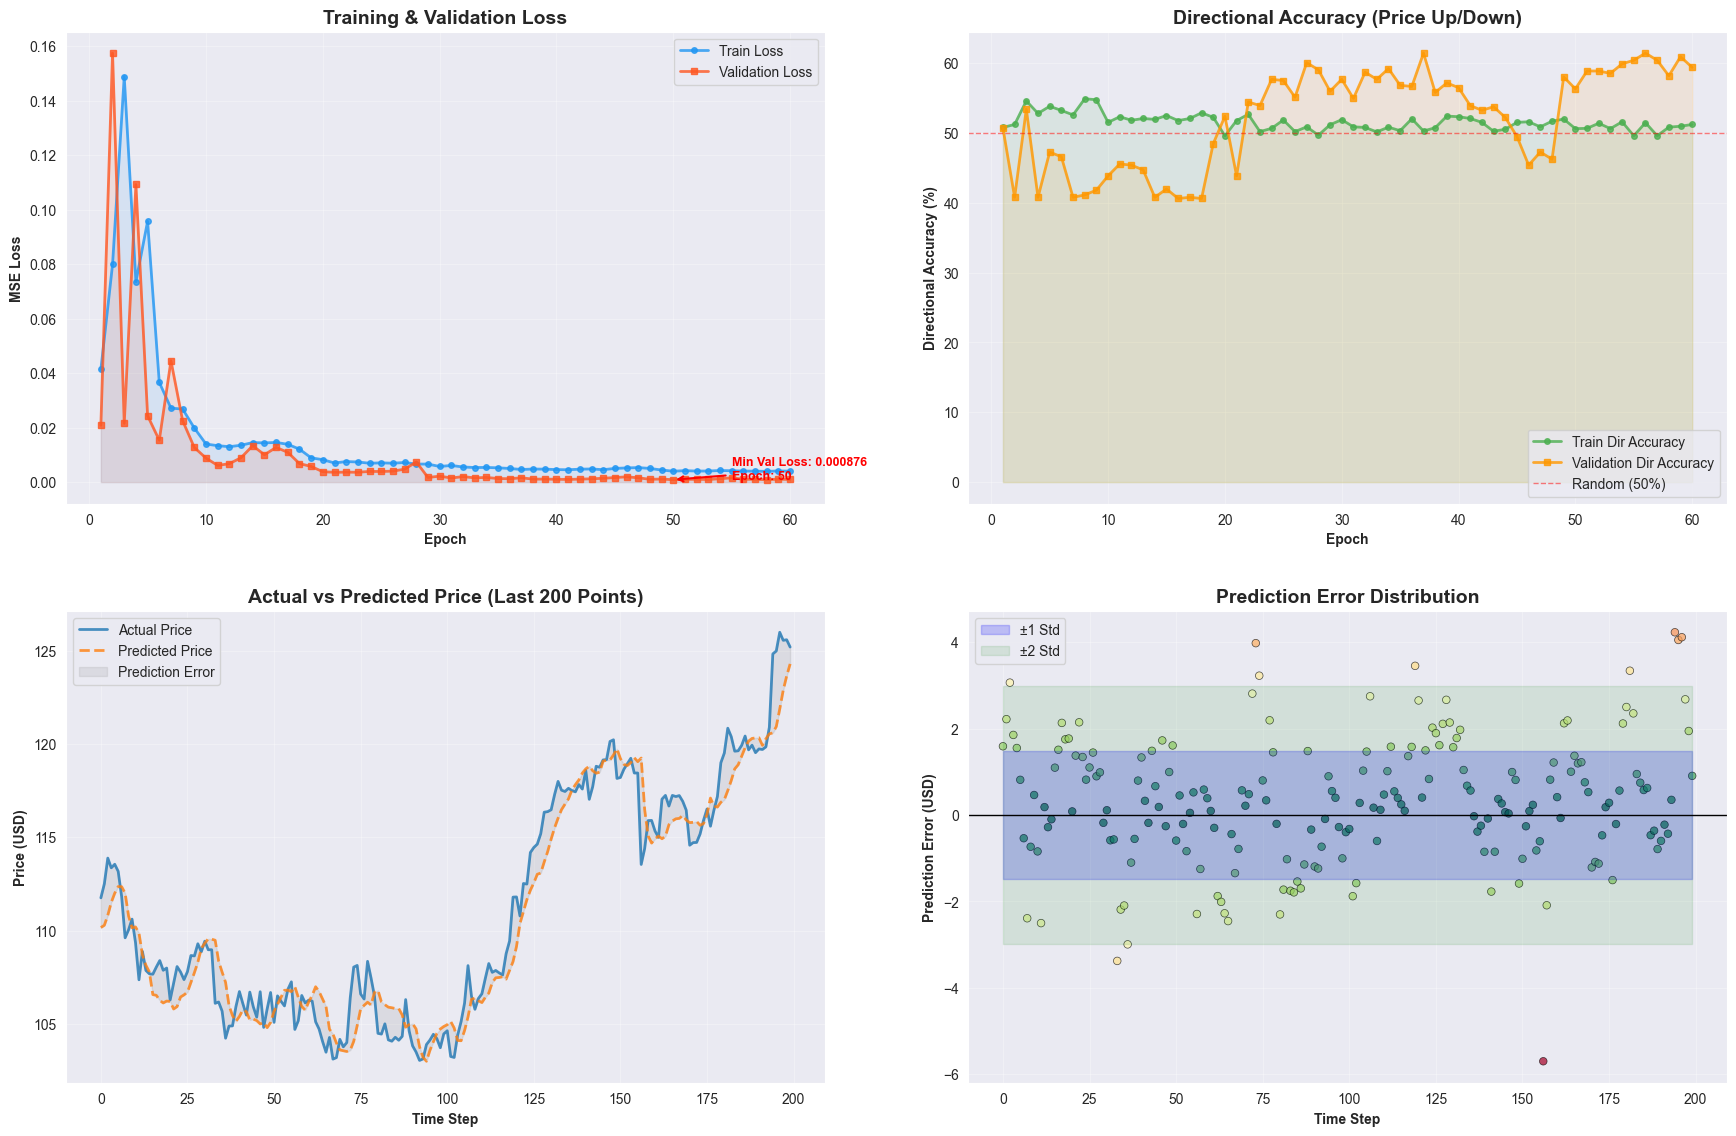


📊 FINAL MODEL METRICS
MAE  (Mean Absolute Error) : 1.7091
MSE  (Mean Squared Error)  : 5.2885
RMSE (Root Mean Squared Error): 2.2997
R² Score                   : 0.9612
Directional Accuracy       : 47.86%
Best Validation Loss       : 0.000876
Total Parameters           : 1,015,298


In [121]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax = axes[0, 0]
epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, color='#2196F3', linewidth=2, label='Train Loss', marker='o', markersize=4, alpha=0.8)
ax.plot(epochs_range, val_losses, color='#FF5722', linewidth=2, label='Validation Loss', marker='s', markersize=4, alpha=0.8)
ax.fill_between(epochs_range, train_losses, alpha=0.1, color='#2196F3')
ax.fill_between(epochs_range, val_losses, alpha=0.1, color='#FF5722')
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('MSE Loss', fontweight='bold')
ax.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

min_loss_epoch = np.argmin(val_losses) + 1
min_loss_val = min(val_losses)
ax.annotate(f'Min Val Loss: {min_loss_val:.6f}\nEpoch: {min_loss_epoch}',
            xy=(min_loss_epoch, min_loss_val), xytext=(min_loss_epoch+5, min_loss_val*1.1),arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=9, color='red', fontweight='bold')

ax = axes[0, 1]
ax.plot(epochs_range, train_accuracies, color='#4CAF50', linewidth=2, label='Train Dir Accuracy', marker='o', markersize=4, alpha=0.8)
ax.plot(epochs_range, val_accuracies, color='#FF9800', linewidth=2, label='Validation Dir Accuracy', marker='s', markersize=4, alpha=0.8)
ax.fill_between(epochs_range, train_accuracies, alpha=0.1, color='#4CAF50')
ax.fill_between(epochs_range, val_accuracies, alpha=0.1, color='#FF9800')
ax.axhline(y=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Random (50%)')
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Directional Accuracy (%)', fontweight='bold')
ax.set_title('Directional Accuracy (Price Up/Down)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
sample_size = min(200, len(y_val_orig))
y_plot = y_val_orig[-sample_size:].flatten()
pred_plot = pred_orig[-sample_size:].flatten()
x_axis = range(len(y_plot))

ax.plot(x_axis, y_plot, color='#1f77b4', linewidth=2, label='Actual Price', alpha=0.8)
ax.plot(x_axis, pred_plot, color='#ff7f0e', linewidth=2, linestyle='--', label='Predicted Price', alpha=0.8)
ax.fill_between(x_axis, y_plot, pred_plot, alpha=0.15, color='gray', label='Prediction Error')
ax.set_xlabel('Time Step', fontweight='bold')
ax.set_ylabel('Price (USD)', fontweight='bold')
ax.set_title(f'Actual vs Predicted Price (Last {sample_size} Points)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
errors = y_plot - pred_plot
ax.scatter(x_axis, errors, c=np.abs(errors), cmap='RdYlGn_r', alpha=0.7, 
           s=30, edgecolors='black', linewidth=0.5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.fill_between(x_axis, -np.std(errors), np.std(errors), alpha=0.2, color='blue', label='±1 Std')
ax.fill_between(x_axis, -2*np.std(errors), 2*np.std(errors), alpha=0.1, color='green', label='±2 Std')
ax.set_xlabel('Time Step', fontweight='bold')
ax.set_ylabel('Prediction Error (USD)', fontweight='bold')
ax.set_title('Prediction Error Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout(pad=3)
plt.show()


mae = mean_absolute_error(y_val_orig, pred_orig)
mse = mean_squared_error(y_val_orig, pred_orig)
rmse = np.sqrt(mse)
r2 = r2_score(y_val_orig, pred_orig)

actual_diff = np.diff(y_val_orig.flatten())
pred_diff = np.diff(pred_orig.flatten())
dir_accuracy = np.mean((actual_diff > 0) == (pred_diff > 0)) * 100

print("\n" + "="*50)
print("📊 FINAL MODEL METRICS")
print("="*50)
print(f"MAE  (Mean Absolute Error) : {mae:.4f}")
print(f"MSE  (Mean Squared Error)  : {mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R² Score                   : {r2:.4f}")
print(f"Directional Accuracy       : {dir_accuracy:.2f}%")
print(f"Best Validation Loss       : {best_val_loss:.6f}")
print(f"Total Parameters           : {sum(p.numel() for p in model.parameters()):,}")
print("="*50)

In [122]:
torch.save(model, 'cvx_close_prediction.pth')